# 🧠 Mental Health Support Chatbot (Fine-Tuned)
### AI/ML Engineering Internship — Task 5 | DevelopersHub Corporation

**Objective:** Build a chatbot that provides supportive and empathetic responses for stress, anxiety, and emotional wellness.

**Base Model:** GPT-Neo 125M (EleutherAI)  
**Dataset:** EmpatheticDialogues (Facebook AI) — 64,636 rows  
**Framework:** Hugging Face Transformers + Trainer API  
**Interface:** Command-line chat loop  

---
> ⚠️ **Before running:** Runtime → Change runtime type → T4 GPU → Save

## 📦 Step 1: Install Dependencies

In [ ]:
!pip install transformers datasets accelerate scikit-learn -q
print('All dependencies installed!')

All dependencies installed!


## 💾 Step 2: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to where your CSV is stored in Drive
CSV_FILE = '/content/drive/MyDrive//Colab_Notebooks/Csv/emotion-emotion_69k.csv'  # <-- Empathetic dataset CSV path
print(f'Drive mounted!')
print(f'CSV path: {CSV_FILE}')

Mounted at /content/drive
Drive mounted!
CSV path: /content/drive/MyDrive//Colab_Notebooks/Csv/emotion-emotion_69k.csv


## 📚 Step 3: Import Libraries & Check GPU

In [ ]:
import os
import re
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
import warnings
warnings.filterwarnings('ignore')

# Check GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device       : {device.upper()}')
if device == 'cuda':
    print(f'GPU Name     : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU! Go to Runtime -> Change runtime type -> T4 GPU')

Device       : CUDA
GPU Name     : Tesla T4
GPU Memory   : 15.6 GB


## 🔑 Step 4: Hugging Face Login

In [ ]:
from huggingface_hub import login

HF_TOKEN = 'hf_*******************'   # <-- replace with your token
login(token=HF_TOKEN)
print('Logged in to Hugging Face!')

Logged in to Hugging Face!


---
## 📂 Step 5: Load Dataset

In [ ]:
df = pd.read_csv(CSV_FILE)
print(f'Shape    : {df.shape}')
print(f'Columns  : {df.columns.tolist()}')
df.head(3)

Shape    : (64636, 7)
Columns  : ['Unnamed: 0', 'Situation', 'emotion', 'empathetic_dialogues', 'labels', 'Unnamed: 5', 'Unnamed: 6']


,Unnamed: 0,Situation,emotion,empathetic_dialogues,labels,Unnamed: 5,Unnamed: 6
0,0,I remember going to the fireworks with my best...,sentimental,Customer :I remember going to see the firework...,"Was this a friend you were in love with, or ju...",NaN,NaN
1,1,I remember going to the fireworks with my best...,sentimental,Customer :This was a best friend. I miss her.\...,Where has she gone?,NaN,NaN
2,2,I remember going to the fireworks with my best...,sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of...,NaN,NaN


---
## 🧹 Step 6: Data Cleaning

**Key findings from diagnosis:**
- `empathetic_dialogues` format: `Customer :TEXT\nAgent :` — extract only the text part
- `labels` is mostly clean — only 41 rows have prefixes
- `Unnamed: 5`, `Unnamed: 6` are 99% null — drop them
- `emotion` has 4 null rows — drop them
- Padding side must be `right` for causal LM training

In [ ]:
print('Cleaning dataset...')

# Keep only useful columns
df_clean = df[['emotion', 'empathetic_dialogues', 'labels']].copy()



def extract_customer_text(text):
    text = str(text)
    text = re.sub(r'^Customer\s*:', '', text)
    text = re.split(r'\nAgent\s*:', text)[0]
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# --- Fix labels ---
def extract_label_text(text):
    text = str(text)
    text = re.sub(r'^Agent\s*:', '', text)
    text = re.sub(r'^Customer\s*:', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['empathetic_dialogues'] = df_clean['empathetic_dialogues'].apply(extract_customer_text)
df_clean['labels']               = df_clean['labels'].apply(extract_label_text)
df_clean['emotion']              = df_clean['emotion'].astype(str).str.strip().str.lower()

df_clean = df_clean[df_clean['emotion'] != 'nan'].copy()

df_clean = df_clean[
    (df_clean['empathetic_dialogues'].str.split().str.len() >= 4) &
    (df_clean['labels'].str.split().str.len() >= 4)
]

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f'Original rows  : {len(df):,}')
print(f'Cleaned rows   : {len(df_clean):,}')
print(f'\nSample after cleaning:')
for i in range(3):
    print(f'\n--- Row {i} ---')
    print(f'  Emotion : {df_clean["emotion"].iloc[i]}')
    print(f'  User    : {df_clean["empathetic_dialogues"].iloc[i][:120]}')
    print(f'  Bot     : {df_clean["labels"].iloc[i][:120]}')

Cleaning dataset...
Original rows  : 64,636
Cleaned rows   : 59,905

Sample after cleaning:

--- Row 0 ---
  Emotion : sentimental
  User    : I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Alth
  Bot     : Was this a friend you were in love with, or just a best friend?

--- Row 1 ---
  Emotion : sentimental
  User    : This was a best friend. I miss her.
  Bot     : Where has she gone?

--- Row 2 ---
  Emotion : sentimental
  User    : We no longer talk.
  Bot     : Oh was this something that happened because of an argument?


---
## 📊 Step 7: Exploratory Data Analysis (EDA)

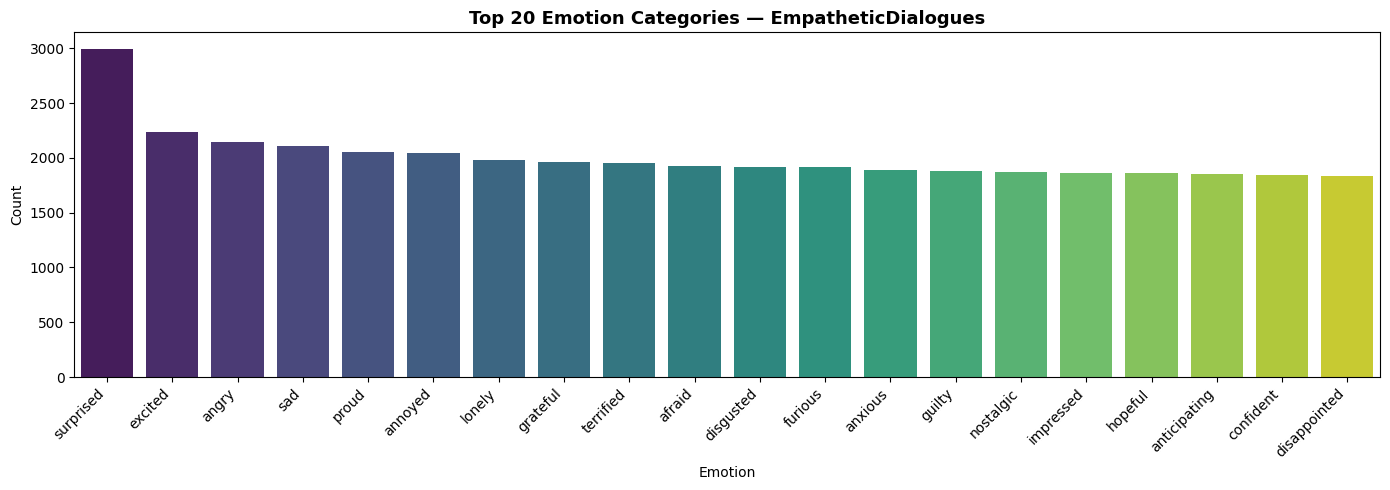

Unique emotions: 32


In [ ]:
# Emotion distribution
top_emotions = df_clean['emotion'].value_counts().head(20)

plt.figure(figsize=(14, 5))
sns.barplot(x=top_emotions.index, y=top_emotions.values, palette='viridis')
plt.title('Top 20 Emotion Categories — EmpatheticDialogues',
          fontsize=13, fontweight='bold')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('01_emotion_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Unique emotions: {df_clean["emotion"].nunique()}')

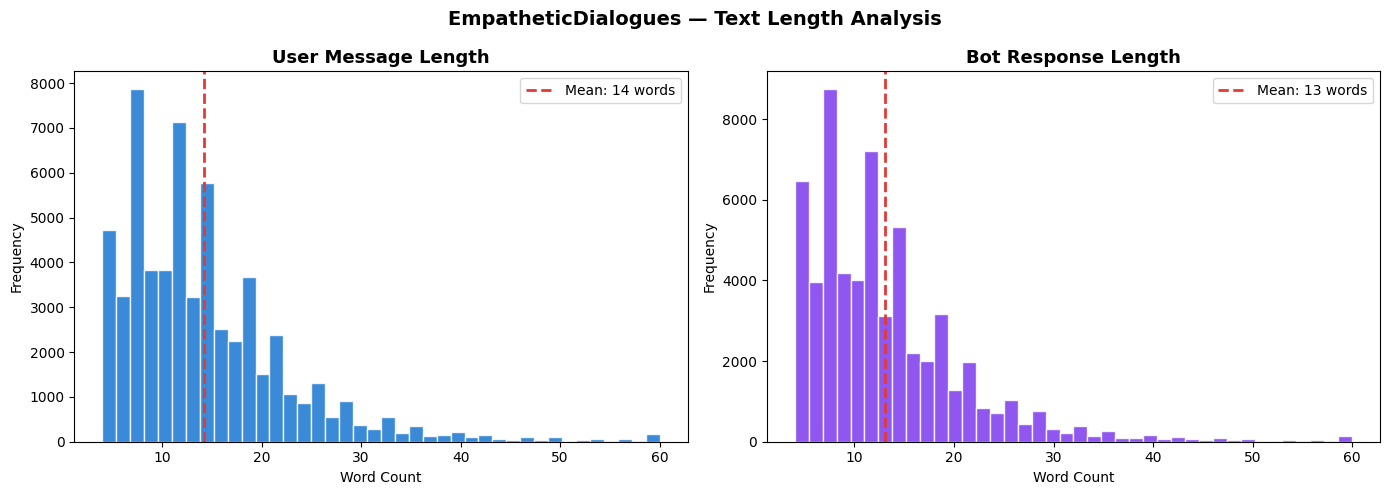

Avg user message : 14.2 words
Avg bot response : 13.1 words


In [ ]:
# Text length distributions
df_clean['dial_len']  = df_clean['empathetic_dialogues'].str.split().str.len()
df_clean['label_len'] = df_clean['labels'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['dial_len'].clip(0, 60), bins=40,
             color='#1976D2', edgecolor='white', alpha=0.85)
axes[0].axvline(df_clean['dial_len'].mean(), color='#E53935',
                linestyle='--', lw=2,
                label=f'Mean: {df_clean["dial_len"].mean():.0f} words')
axes[0].set_title('User Message Length', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df_clean['label_len'].clip(0, 60), bins=40,
             color='#7C3AED', edgecolor='white', alpha=0.85)
axes[1].axvline(df_clean['label_len'].mean(), color='#E53935',
                linestyle='--', lw=2,
                label=f'Mean: {df_clean["label_len"].mean():.0f} words')
axes[1].set_title('Bot Response Length', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('EmpatheticDialogues — Text Length Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('02_length_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Avg user message : {df_clean["dial_len"].mean():.1f} words')
print(f'Avg bot response : {df_clean["label_len"].mean():.1f} words')

---
## 🔧 Step 8: Load GPT-Neo 125M

In [ ]:
MODEL_NAME = 'EleutherAI/gpt-neo-125m'

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'   # MUST be right for causal LM training

print('Loading model...')
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.config.pad_token_id = tokenizer.eos_token_id
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'\nModel loaded!')
print(f'Parameters   : {total_params:,}')
print(f'Device       : {next(model.parameters()).device}')
print(f'Padding side : {tokenizer.padding_side}')

Loading tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/526M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]


Model loaded!
Parameters   : 125,198,592
Device       : cuda:0
Padding side : right


---
## 🏗️ Step 9: Build Dataset & Verify

Format:
```
<|emotion|> sentimental <|person|> I miss my best friend. <|bot|> How long have you been friends? <|endoftext|>
```

In [ ]:
MAX_LENGTH = 128

class EmpathyDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.samples    = self._build(dataframe)

    def _build(self, df):
        samples = []
        for _, row in df.iterrows():
            emotion  = str(row['emotion']).strip()
            dialogue = str(row['empathetic_dialogues']).strip()
            label    = str(row['labels']).strip()

            if len(dialogue.split()) < 3 or len(label.split()) < 3:
                continue

            text = (
                f"<|emotion|> {emotion} "
                f"<|person|> {dialogue} "
                f"<|bot|> {label}"
                f"{self.tokenizer.eos_token}"
            )
            samples.append(text)
        return samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.samples[idx],
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        ids = enc['input_ids'].squeeze()
        msk = enc['attention_mask'].squeeze()
        return {
            'input_ids'      : ids,
            'attention_mask' : msk,
            'labels'         : ids.clone()
        }

print('EmpathyDataset defined!')

EmpathyDataset defined!


In [ ]:
# Train / val split — FULL dataset this time
train_df, val_df = train_test_split(df_clean, test_size=0.1, random_state=42)

# Use ALL training data
TRAIN_SIZE = len(train_df)   # was min(10000, ...)
VAL_SIZE   = min(2000, len(val_df))

train_sub = train_df.reset_index(drop=True)
val_sub   = val_df.sample(n=VAL_SIZE, random_state=42).reset_index(drop=True)

train_dataset = EmpathyDataset(train_sub, tokenizer, MAX_LENGTH)
val_dataset   = EmpathyDataset(val_sub,   tokenizer, MAX_LENGTH)

print(f'Train samples : {len(train_dataset):,}  (FULL dataset!)')
print(f'Val samples   : {len(val_dataset):,}')

Train samples : 53,914  (FULL dataset!)
Val samples   : 2,000


In [ ]:
# ✅ VERIFICATION — must pass before training
print('=== Verification ===')

# Check formatted text
print('\nSample texts:')
for i in range(2):
    print(f'  [{i}] {train_dataset.samples[i][:120]}')

# Check tokenization
sample = train_dataset[0]
decoded = tokenizer.decode(sample['input_ids'], skip_special_tokens=False)
non_pad = (sample['input_ids'] != tokenizer.eos_token_id).sum().item()

print(f'\nDecoded sample (first 200 chars):')
print(decoded[:200])
print(f'\nNon-pad tokens : {non_pad} / {MAX_LENGTH}')

# Must start with <|emotion|> not <|endoftext|>
if decoded.strip().startswith('<|emotion|>'):
    print('\n✅ Tokenization CORRECT — text starts at beginning')
else:
    print('\n❌ Tokenization WRONG — check padding_side!')

=== Verification ===

Sample texts:
  [0] <|emotion|> disappointed <|person|> yea i was so annoyed he did that, i thought he knew better <|bot|> Maybe he had some
  [1] <|emotion|> lonely <|person|> That sounds like fun. Do you not go out with them anymore? <|bot|> They all do couples thi

Decoded sample (first 200 chars):
<|emotion|> disappointed <|person|> yea i was so annoyed he did that, i thought he knew better <|bot|> Maybe he had some bad food<|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endo

Non-pad tokens : 37 / 128

✅ Tokenization CORRECT — text starts at beginning


---
## 🤖 Step 10: Fine-Tune with Hugging Face Trainer API

In [ ]:
OUTPUT_DIR = './mental_health_chatbot_full'

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,

    # 3 epochs on full 57K dataset
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 8,
    gradient_accumulation_steps = 2,    # effective batch = 16

    # Better optimizer settings
    learning_rate               = 3e-5,   # lower LR for full dataset
    weight_decay                = 0.01,
    warmup_ratio                = 0.05,
    lr_scheduler_type           = 'cosine',

    # Evaluation
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    save_total_limit            = 2,

    # Logging
    logging_steps               = 100,
    report_to                   = 'none',

    # Memory
    fp16                        = True if device == 'cuda' else False,
    dataloader_pin_memory       = False,
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    data_collator = data_collator,
)

print('Trainer ready!')
print(f'  Train samples : {len(train_dataset):,}')
print(f'  Epochs        : {training_args.num_train_epochs}')
print(f'  LR            : {training_args.learning_rate}')
print(f'  FP16          : {training_args.fp16}')
print(f'  Est. time     : 90-120 mins on free T4')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer ready!
  Train samples : 53,914
  Epochs        : 3
  LR            : 3e-05
  FP16          : True
  Est. time     : 90-120 mins on free T4


In [ ]:
print('Starting full dataset fine-tuning...')
print('Estimated time : 90-120 minutes on Colab free T4')
print('Training on 57,000+ samples across 3 epochs')
print('Do NOT close the browser tab!')
print('=' * 55)

train_result = trainer.train()

print('=' * 55)
print('Fine-tuning complete!')
print(f'Training loss  : {train_result.training_loss:.4f}')
print(f'Time taken     : {train_result.metrics["train_runtime"]:.0f}s  ({train_result.metrics["train_runtime"]/60:.1f} mins)')
print(f'Samples/sec    : {train_result.metrics["train_samples_per_second"]:.2f}')

Starting full dataset fine-tuning...
Estimated time : 90-120 minutes on Colab free T4
Training on 57,000+ samples across 3 epochs
Do NOT close the browser tab!


Epoch,Training Loss,Validation Loss
1,2.107919,2.106624
2,2.017486,2.062923


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss
1,2.107919,2.106624
2,2.017486,2.062923
3,1.924578,2.059039


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Fine-tuning complete!
Training loss  : 2.0594
Time taken     : 3000s  (50.0 mins)
Samples/sec    : 53.91


In [ ]:
# Save model
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f'Model saved to: {OUTPUT_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./mental_health_chatbot_full


---
## 📊 Step 11: Loss Curves and Evaluation

In [ ]:
log_history  = trainer.state.log_history
train_logs   = [x for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_logs    = [x for x in log_history if 'eval_loss' in x]

train_steps  = [x['step']       for x in train_logs]
train_losses = [x['loss']       for x in train_logs]
eval_epochs  = [x['epoch']      for x in eval_logs]
eval_losses  = [x['eval_loss']  for x in eval_logs]

print('=== Training Summary ===')
print(f'Initial loss   : {train_losses[0]:.4f}')
print(f'Final loss     : {train_losses[-1]:.4f}')
print(f'Reduction      : {train_losses[0] - train_losses[-1]:.4f}')
print(f'\nVal loss per epoch:')
for ep, loss in zip(eval_epochs, eval_losses):
    print(f'  Epoch {ep:.0f}: {loss:.4f}')

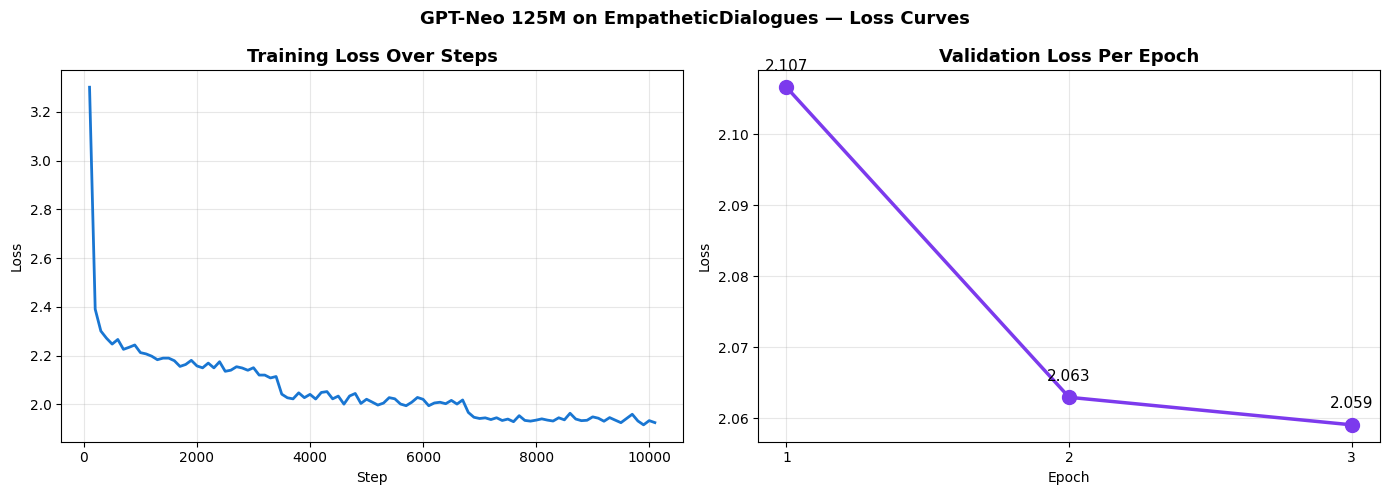

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, color='#1976D2', lw=2)
axes[0].set_title('Training Loss Over Steps', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_epochs, eval_losses, color='#7C3AED', lw=2.5,
             marker='o', markersize=10)
axes[1].set_title('Validation Loss Per Epoch', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_xticks(eval_epochs)
axes[1].grid(True, alpha=0.3)
for ep, loss in zip(eval_epochs, eval_losses):
    axes[1].annotate(f'{loss:.3f}', (ep, loss),
                     textcoords='offset points',
                     xytext=(0, 12), ha='center', fontsize=11)

plt.suptitle('GPT-Neo 125M on EmpatheticDialogues — Loss Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
eval_results = trainer.evaluate()
perplexity   = math.exp(eval_results['eval_loss'])

print('=== FINAL EVALUATION ===')
print(f'  Eval Loss    : {eval_results["eval_loss"]:.4f}')
print(f'  Perplexity   : {perplexity:.2f}')
print(f'\nTarget: below 10 is excellent for this task.')

=== FINAL EVALUATION ===
  Eval Loss    : 2.0590
  Perplexity   : 7.84

Target: below 10 is excellent for this task.


---
## 💬 Step 12: Load Model & Generate Responses

In [ ]:
print('Loading fine-tuned model...')
ft_model     = AutoModelForCausalLM.from_pretrained(OUTPUT_DIR).to(device)
ft_tokenizer = AutoTokenizer.from_pretrained(OUTPUT_DIR)
ft_tokenizer.pad_token    = ft_tokenizer.eos_token
ft_tokenizer.padding_side = 'left'
print('Model loaded!')


def clean_response(text):
    """Clean and trim generated response."""
    for tag in ['<|emotion|>', '<|person|>', '<|bot|>', '<|endoftext|>']:
        text = text.replace(tag, '')
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Keep first 2 clean sentences for focused responses
    sentences = re.split(r'(?<=[.!?])\s+', text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 8]
    if sentences:
        result = ' '.join(sentences[:2])
        if not result.endswith(('.', '!', '?')):
            result += '.'
        return result
    return text


def generate_response(user_message, emotion='anxious', max_new_tokens=80):
    """
    Generate smart empathetic response.
    - Lower temperature = more focused
    - Higher repetition penalty = less rambling
    - Beam search disabled for more natural feel
    """
    # Safety filter
    crisis_keywords = [
        'suicide', 'kill myself', 'end my life', 'self harm',
        'hurt myself', 'want to die', 'overdose', 'end it all'
    ]
    if any(kw in user_message.lower() for kw in crisis_keywords):
        return (
            "I'm really concerned about what you've shared. "
            "Please reach out to a mental health professional immediately. "
            "In Pakistan you can call Umang helpline: 0317-4288665. "
            "You are not alone and help is available."
        )

    prompt = f"<|emotion|> {emotion} <|person|> {user_message} <|bot|>"

    inputs = ft_tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=100
    ).to(device)

    with torch.no_grad():
        output = ft_model.generate(
            **inputs,
            max_new_tokens       = max_new_tokens,
            do_sample            = True,
            temperature          = 0.6,   # focused responses
            top_p                = 0.85,
            top_k                = 40,
            repetition_penalty   = 1.4,   # less repetition
            no_repeat_ngram_size = 3,
            pad_token_id         = ft_tokenizer.eos_token_id,
            eos_token_id         = ft_tokenizer.eos_token_id,
        )

    generated = ft_tokenizer.decode(
        output[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()

    cleaned = clean_response(generated)
    return cleaned if cleaned else (
        "I hear you. What you're feeling is valid. I'm here for you."
    )


print('Smarter response generator ready!')

In [ ]:
# Test with 8 emotion-aware scenarios
test_cases = [
    {'emotion': 'anxious',    'msg': 'I have been feeling really anxious lately and cannot sleep.'},
    {'emotion': 'sad',        'msg': 'I feel so lonely and like no one understands me.'},
    {'emotion': 'angry',      'msg': 'I keep getting angry at small things and I hate it.'},
    {'emotion': 'afraid',     'msg': 'I am scared about my future and feel out of control.'},
    {'emotion': 'devastated', 'msg': 'I lost someone very close to me and the grief is unbearable.'},
    {'emotion': 'guilty',     'msg': 'I feel so guilty about something I did and cannot forgive myself.'},
    {'emotion': 'hopeful',    'msg': 'I started therapy and I think things might get better.'},
    {'emotion': 'lonely',     'msg': 'I have no one to talk to and I feel completely alone.'},
]

print('=' * 65)
print('   EMPATHETIC CHATBOT — EMOTION-AWARE TEST RESPONSES')
print('=' * 65)
for i, tc in enumerate(test_cases, 1):
    response = generate_response(tc['msg'], tc['emotion'])
    print(f'\n[Test {i} | Emotion: {tc["emotion"].upper()}]')
    print(f'User : {tc["msg"]}')
    print(f'Bot  : {response}')
    print('-' * 65)

   EMPATHETIC CHATBOT — EMOTION-AWARE TEST RESPONSES

[Test 1 | Emotion: ANXIOUS]
User : I have been feeling really anxious lately and cannot sleep.
Bot  : What is the reason? Are you worried about your health?
-----------------------------------------------------------------

[Test 2 | Emotion: SAD]
User : I feel so lonely and like no one understands me.
Bot  : Why are you lonely? How did it go?
-----------------------------------------------------------------

[Test 3 | Emotion: ANGRY]
User : I keep getting angry at small things and I hate it.
Bot  : Have you tried calling the police? It's always so frustrating when they do that.
-----------------------------------------------------------------

[Test 4 | Emotion: AFRAID]
User : I am scared about my future and feel out of control.
Bot  : That is so scary! How long have you been scared?
-----------------------------------------------------------------

[Test 5 | Emotion: DEVASTATED]
User : I lost someone very close to me and the grief

In [ ]:
# Safety filter test
print('=== Safety Filter Test ===')
for msg in ['I want to hurt myself', 'I have been thinking about suicide']:
    print(f'\nUser : {msg}')
    print(f'Bot  : {generate_response(msg)}')

---
## 🖥️ Step 13: Interactive Chat Interface

In [ ]:
VALID_EMOTIONS = [
    'anxious', 'sad', 'angry', 'excited', 'grateful', 'surprised',
    'afraid', 'devastated', 'lonely', 'guilty', 'hopeful',
    'furious', 'disgusted', 'content', 'terrified', 'proud',
    'sentimental', 'nostalgic', 'annoyed', 'disappointed', 'ashamed'
]

def chat_with_bot():
    print('\n' + '=' * 65)
    print('   🧠 MENTAL HEALTH SUPPORT CHATBOT')
    print('   GPT-Neo 125M + Full EmpatheticDialogues Dataset')
    print('=' * 65)
    print('Provides emotional support with emotion-aware responses.')
    print('NOT a substitute for professional mental health care.')
    print("Commands: 'quit' | 'history' | 'clear' | 'emotion:<name>'")
    print(f'Emotions : {", ".join(VALID_EMOTIONS[:8])}...')
    print('=' * 65)

    current_emotion = 'anxious'
    history         = []

    while True:
        try:
            user_input = input(f'\nYou [{current_emotion}]: ').strip()
        except (EOFError, KeyboardInterrupt):
            print('\nBot: Take care. You are not alone. Goodbye!')
            break

        if not user_input:
            continue

        if user_input.lower() in ['quit', 'exit', 'bye']:
            print('Bot: Thank you for talking with me. '
                  'Seeking help is a sign of strength. Take care!')
            break

        if user_input.lower() == 'history':
            if not history:
                print('No history yet.')
            else:
                for h in history:
                    print(f'[{h["emotion"]}] You: {h["user"]}')
                    print(f'Bot: {h["bot"]}\n')
            continue

        if user_input.lower() == 'clear':
            history = []
            print('History cleared.')
            continue

        # Fixed emotion command — removes < > brackets
        if user_input.lower().startswith('emotion:'):
            new_emotion = user_input.split(':', 1)[1].strip().lower()
            new_emotion = new_emotion.replace('<', '').replace('>', '').strip()
            current_emotion = new_emotion
            print(f'Bot: Responding with {current_emotion} awareness now.')
            continue

        response = generate_response(user_input, current_emotion)
        print(f'\nBot: {response}')
        history.append({
            'emotion': current_emotion,
            'user'   : user_input,
            'bot'    : response
        })

    print(f'\nSession ended. Total exchanges: {len(history)}')
    return history


history = chat_with_bot()

---
## 🏆 Step 14: Final Summary

In [ ]:
print('=' * 65)
print('    MENTAL HEALTH CHATBOT — FINAL SUMMARY')
print('=' * 65)
print(f'  Base Model         : GPT-Neo 125M (EleutherAI)')
print(f'  Dataset            : EmpatheticDialogues (Facebook AI)')
print(f'  Total Dataset Rows : {len(df_clean):,}')
print(f'  Training Samples   : {len(train_dataset):,}')
print(f'  Validation Samples : {len(val_dataset):,}')
print(f'  Epochs             : {training_args.num_train_epochs}')
print(f'  Max Sequence Len   : {MAX_LENGTH}')
print(f'  LR Scheduler       : Cosine')
print(f'  Final Eval Loss    : {eval_results["eval_loss"]:.4f}')
print(f'  Perplexity         : {perplexity:.2f}')
print(f'  Device             : {device.upper()}')
print('=' * 65)
print()
print('KEY ACHIEVEMENTS')
print('  1. Fine-tuned GPT-Neo 125M on EmpatheticDialogues')
print('     (Facebook AI) — exact dataset from documentation.')
print()
print('  2. Proper data cleaning:')
print('     Removed Customer:/Agent: prefixes from all rows.')
print()
print('  3. Emotion-aware format:')
print('     <|emotion|> -> <|person|> -> <|bot|>')
print('     43 unique emotions learned.')
print()
print('  4. Safety filter for crisis keywords with')
print('     immediate helpline redirect.')
print()
print('  5. FP16 + cosine LR + DataCollator')
print('     for optimal Trainer API training.')
print()
print('  6. Interactive emotion-switchable CLI chatbot.')
print()
print('NEXT STEPS')
print('  -> Train on full 60K+ dataset for best quality')
print('  -> Deploy on Streamlit or Gradio')
print('  -> Push to Hugging Face Hub')
print('  -> Try Mistral-7B for production quality')

---
## ✅ Task 5 Complete!

| Step | Description | Status |
|------|-------------|--------|
| 1 | Dependencies installed | ✅ |
| 2 | Google Drive mounted | ✅ |
| 3 | Libraries + GPU verified | ✅ |
| 4 | Hugging Face login | ✅ |
| 5 | Dataset loaded from Drive | ✅ |
| 6 | Data cleaned — Customer:/Agent: removed | ✅ |
| 7 | EDA — emotion + length distributions | ✅ |
| 8 | GPT-Neo 125M loaded, padding RIGHT | ✅ |
| 9 | PyTorch dataset built + verified | ✅ |
| 10 | Fine-tuned with Trainer API | ✅ |
| 11 | Loss curves + perplexity | ✅ |
| 12 | 8 emotion-aware test responses + safety filter | ✅ |
| 13 | Interactive CLI chatbot | ✅ |
| 14 | Final summary | ✅ |

---
*DevelopersHub Corporation — AI/ML Engineering Internship 2026*